# 01. 탐색적 데이터 분석 (EDA)
## Credit Card Fraud Detection
---
**데이터**: Kaggle Credit Card Fraud Dataset (2013년 유럽 카드사 실거래)  
**목표**: 284,807건 거래에서 492건(0.17%) 사기 탐지  
**키 챌린지**: 극단적 클래스 불균형, PCA 익명화 피처

> 실제 데이터: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
> `data/creditcard.csv` 에 저장 후 실행하세요.


In [22]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_config, set_seed, get_logger
from src.data_loader import load_data, describe_data
import importlib
import src.visualize as viz
viz = importlib.reload(viz)  # reload edited visualization labels in an existing notebook kernel
plot_class_distribution = viz.plot_class_distribution
plot_amount_distribution = viz.plot_amount_distribution

cfg = load_config('../configs/config.yaml')
set_seed(cfg['project']['seed'])
logger = get_logger('EDA')

print("설정 로드 완료")
print(f"프로젝트: {cfg['project']['name']} v{cfg['project']['version']}")

설정 로드 완료
프로젝트: credit-fraud-mlpipeline v1.0.0


In [23]:
# ── 데이터 로드 ─────────────────────────────────────────────
df = load_data(cfg)
print(f"\n데이터 크기: {df.shape}")
df.head()

14:03:32 | INFO | src.data_loader | 실제 데이터 로드: ../data/creditcard.csv
14:03:33 | INFO | src.data_loader | 로드 완료: (284807, 31) | 사기율: 0.1727%



데이터 크기: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
# ── 기초 통계 ───────────────────────────────────────────────
stats = describe_data(df)
print(f"총 거래:   {stats['total']:,}건")
print(f"사기:      {stats['fraud_count']:,}건  ({stats['fraud_rate']:.4%})")
print(f"정상:      {stats['normal_count']:,}건")
print(f"\n거래 금액:")
print(f"  정상 평균:  ${stats['amount_stats']['normal_mean']:.2f}")
print(f"  사기 평균:  ${stats['amount_stats']['fraud_mean']:.2f}")
print(f"  정상 중앙값: ${stats['amount_stats']['normal_median']:.2f}")
print(f"  사기 중앙값: ${stats['amount_stats']['fraud_median']:.2f}")
print(f"\n결측치: {sum(stats['null_counts'].values())}개")
print(f"중복 행: {stats['duplicates']:,}개")

총 거래:   284,807건
사기:      492건  (0.1727%)
정상:      284,315건

거래 금액:
  정상 평균:  $88.29
  사기 평균:  $122.21
  정상 중앙값: $22.00
  사기 중앙값: $9.25

결측치: 0개
중복 행: 1,081개


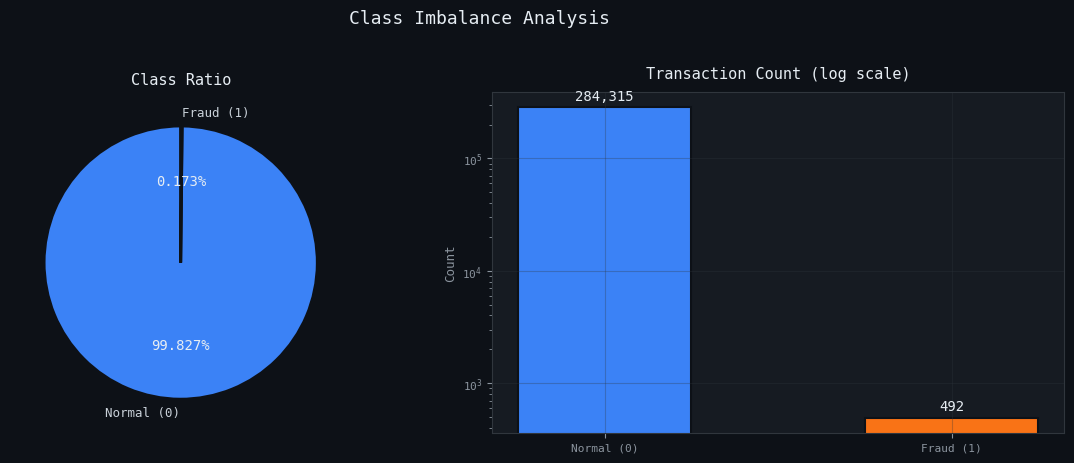


이 불균형 수준에서 단순 정확도는 의미없음
   항상 '정상'으로 예측해도 정확도 = 99.8273%


In [4]:
# ── 클래스 불균형 시각화 ────────────────────────────────────
viz = importlib.reload(viz)
fig = viz.plot_class_distribution(df['Class'], save_path='../outputs/figures/01_class_dist.png')
plt.show()
print("\n이 불균형 수준에서 단순 정확도는 의미없음")
print(f"   항상 '정상'으로 예측해도 정확도 = {1 - stats['fraud_rate']:.4%}")

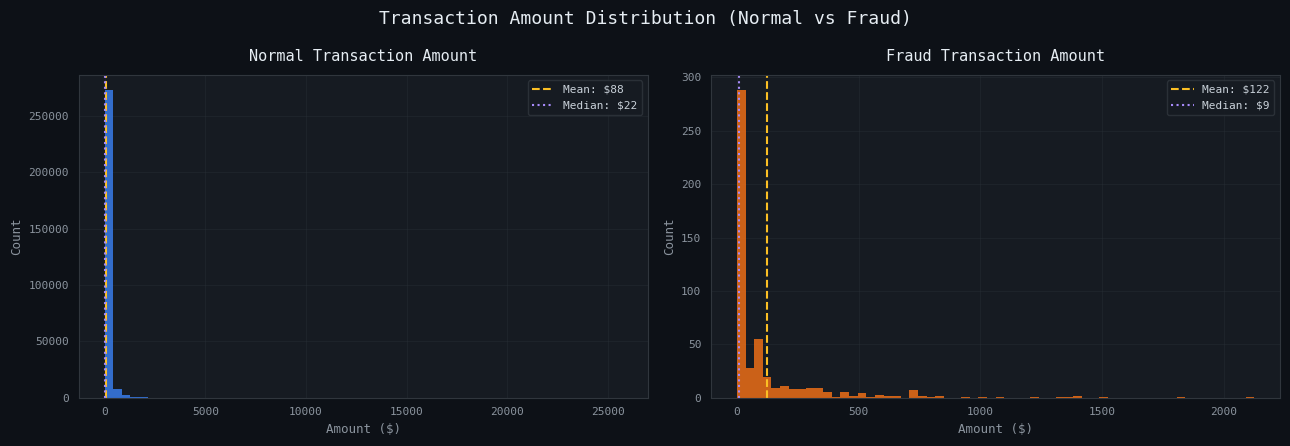

In [26]:
# ── 거래 금액 분포 ──────────────────────────────────────────
viz = importlib.reload(viz)
fig = viz.plot_amount_distribution(df, save_path='../outputs/figures/02_amount_dist.png')
plt.show()

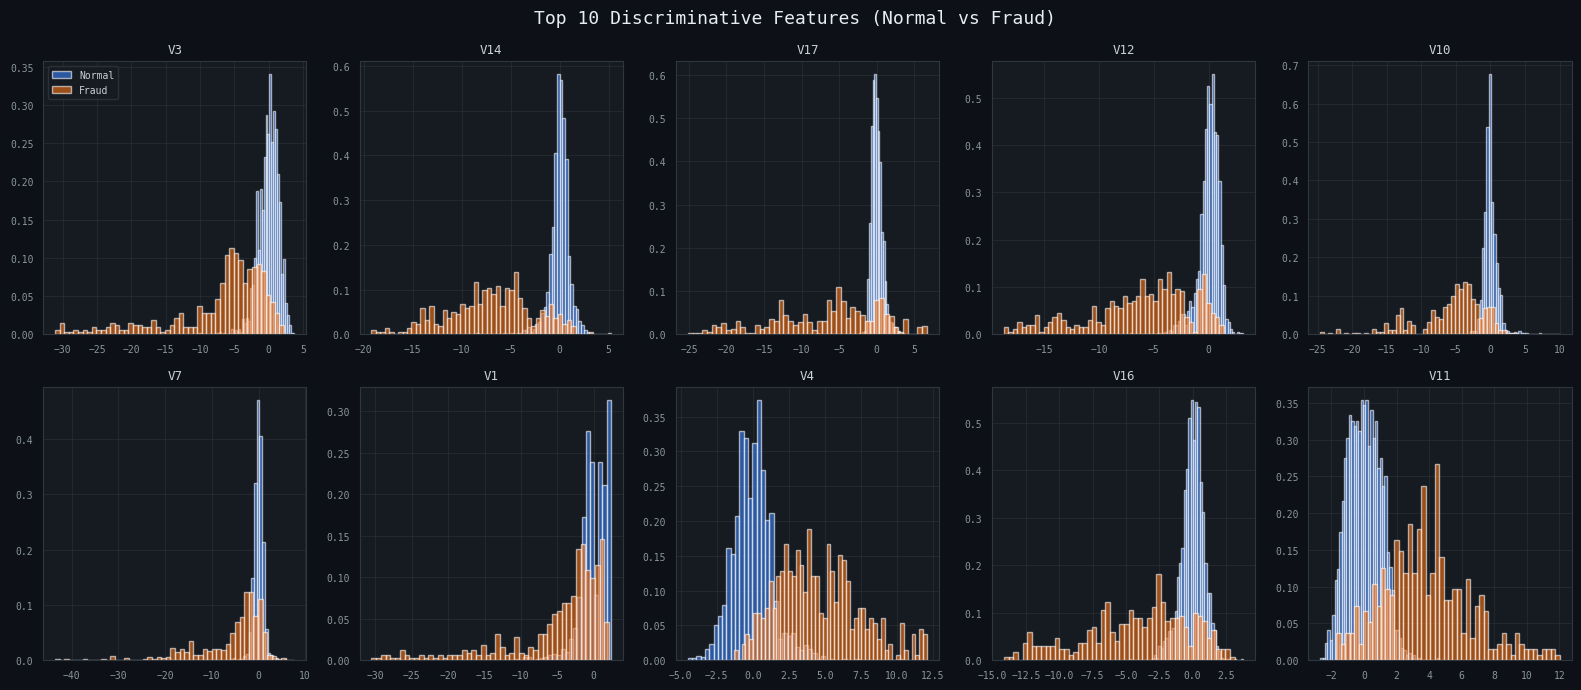


가장 변별력 높은 피처 Top 10:
V3     7.006
V14    6.963
V17    6.711
V12    6.273
V10    5.692
V7     5.561
V1     4.741
V4     4.564
V16    4.126
V11    3.801


In [27]:
# ── V 피처 분포 비교 (정상 vs 사기) ───────────────────────
# 실제 데이터에서 사기와 가장 큰 차이를 보이는 피처 식별
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(2000, random_state=42)  # 시각화용 다운샘플

# 각 V 피처의 정상/사기 평균 차이 절대값
v_cols = [f'V{i}' for i in range(1, 29)]
diff = (fraud[v_cols].mean() - normal[v_cols].mean()).abs().sort_values(ascending=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Top 10 Discriminative Features (Normal vs Fraud)', fontsize=13, color='#e6edf3')

for ax, col in zip(axes.flat, diff.head(10).index):
    ax.set_facecolor('#161b22')
    ax.hist(normal[col], bins=50, alpha=0.6, color='#3b82f6', label='Normal', density=True)
    ax.hist(fraud[col],  bins=50, alpha=0.6, color='#f97316', label='Fraud', density=True)
    ax.set_title(col, fontsize=9, color='#c9d1d9')
    ax.tick_params(labelsize=7, colors='#8b949e')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')
    if ax == axes[0][0]: ax.legend(fontsize=7, facecolor='#161b22', edgecolor='#30363d')

plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_dist.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n가장 변별력 높은 피처 Top 10:")
print(diff.head(10).round(3).to_string())

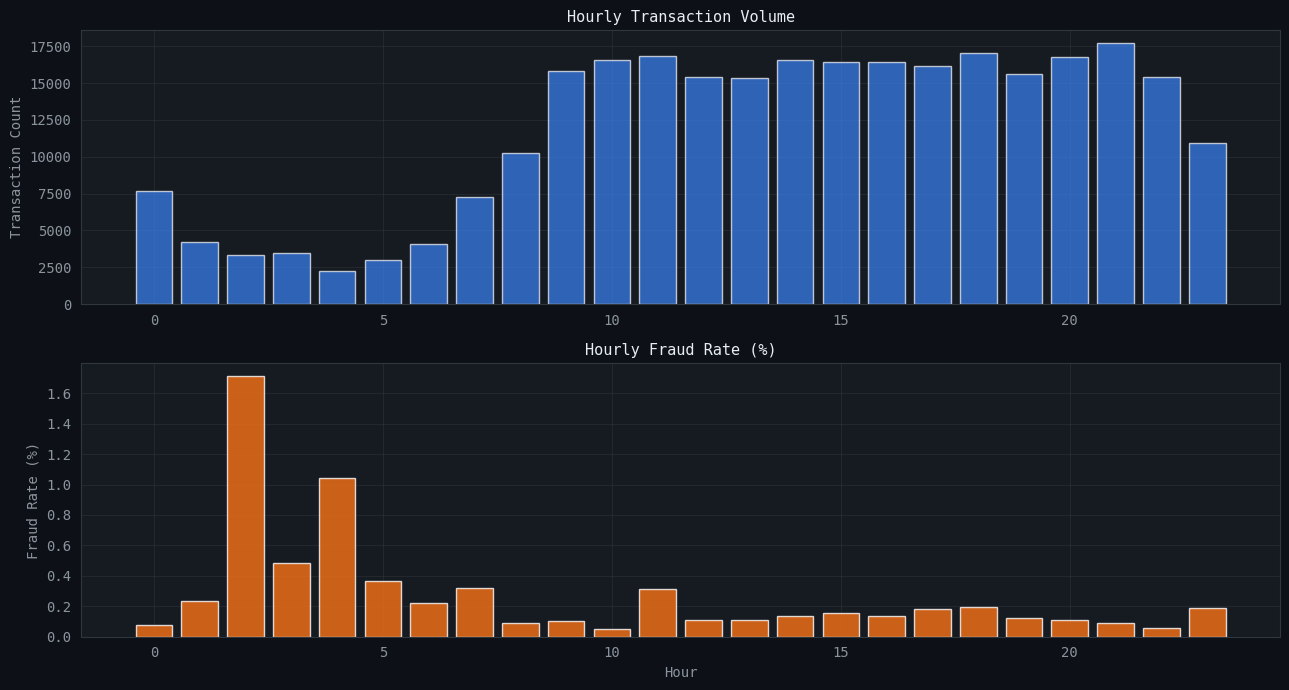


사기율 최고 시간대: 2시 (1.7127%)


In [28]:
# ── 시간대별 사기 패턴 ─────────────────────────────────────
df['Hour'] = (df['Time'] % 86400 // 3600).astype(int)

hourly = df.groupby('Hour')['Class'].agg(['sum', 'count', 'mean']).reset_index()
hourly.columns = ['Hour', 'FraudCount', 'TotalTransactions', 'FraudRate']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
fig.patch.set_facecolor('#0d1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

ax1.bar(hourly['Hour'], hourly['TotalTransactions'], color='#3b82f6', alpha=0.7, label='Total transactions')
ax1.set_title('Hourly Transaction Volume', fontsize=11, color='#e6edf3')
ax1.set_ylabel('Transaction Count', color='#8b949e')
ax1.tick_params(colors='#8b949e')

ax2.bar(hourly['Hour'], hourly['FraudRate'] * 100, color='#f97316', alpha=0.8, label='Fraud rate')
ax2.set_title('Hourly Fraud Rate (%)', fontsize=11, color='#e6edf3')
ax2.set_xlabel('Hour', color='#8b949e')
ax2.set_ylabel('Fraud Rate (%)', color='#8b949e')
ax2.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('../outputs/figures/04_hourly_fraud.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

peak_hour = hourly.loc[hourly['FraudRate'].idxmax(), 'Hour']
print(f"\n사기율 최고 시간대: {peak_hour}시 ({hourly.loc[hourly['FraudRate'].idxmax(), 'FraudRate']:.4%})")

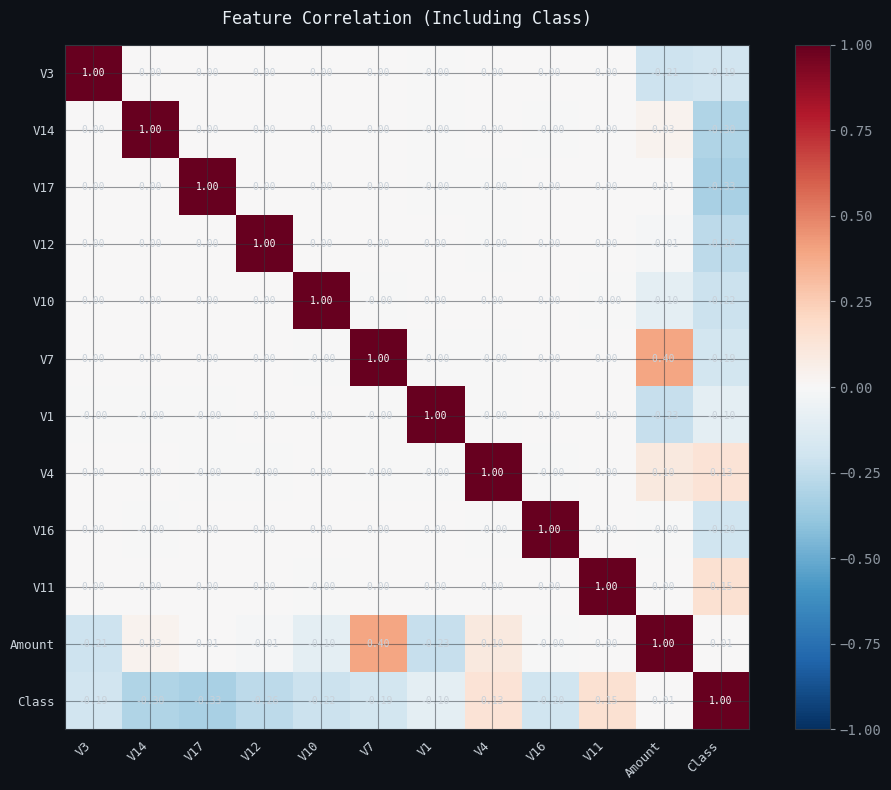

In [29]:
# ── 상관관계 히트맵 (Top 피처) ──────────────────────────────
top_feats = diff.head(10).index.tolist() + ['Amount', 'Class']
corr = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

import matplotlib.colors as mcolors
cmap = plt.cm.RdBu_r
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(top_feats))); ax.set_yticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=45, ha='right', fontsize=9, color='#c9d1d9')
ax.set_yticklabels(top_feats, fontsize=9, color='#c9d1d9')

for i in range(len(top_feats)):
    for j in range(len(top_feats)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(val) > 0.5 else '#c9d1d9')

plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Feature Correlation (Including Class)', fontsize=12, color='#e6edf3', pad=15)
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('../outputs/figures/05_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [32]:
# ── EDA 요약 및 모델링 전략 ────────────────────────────────
print("="*60)
print("  EDA 핵심 인사이트")
print("="*60)
print("""
1. 클래스 불균형 (0.17%)
   → 평가: ROC-AUC 대신 Average Precision 사용
   → 처리: SMOTE + class_weight 실험

2. V1, V3, V4, V10, V12, V14 피처가 가장 변별력 높음
   → PCA 변환된 거래 패턴 피처
   → Feature selection 고려 가능

3. Amount 분포가 정상/사기 간 차이 있음
   → log1p 변환으로 스케일 조정 필요

4. 시간대별 패턴 존재
   → Hour, IsNight 파생 피처 추가

5. 중복 행 존재 시 제거 필요 (실제 데이터 기준)
""")

  EDA 핵심 인사이트

1. 클래스 불균형 (0.17%)
   → 평가: ROC-AUC 대신 Average Precision 사용
   → 처리: SMOTE + class_weight 실험

2. V1, V3, V4, V10, V12, V14 피처가 가장 변별력 높음
   → PCA 변환된 거래 패턴 피처
   → Feature selection 고려 가능

3. Amount 분포가 정상/사기 간 차이 있음
   → log1p 변환으로 스케일 조정 필요

4. 시간대별 패턴 존재
   → Hour, IsNight 파생 피처 추가

5. 중복 행 존재 시 제거 필요 (실제 데이터 기준)

